In [29]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
import re

In [177]:
df_Q_US = pd.read_csv('Quarterly US GARCH MIDAS R v4.csv')
df_Month_Sector = pd.read_csv('Monthly Sector GARCH MIDAS R v2.csv')
df_Month_US = pd.read_csv('Monthly US GARCH MIDAS R v1.csv')
Quarterly = pd.read_csv('Quarterly.csv', parse_dates = True, index_col = [0])
Sector_Returns = pd.read_csv('Sector_Indices_2005_2025.csv', parse_dates=True, index_col = [0])

In [127]:
def Reformat_GARCH_Analysis(df : pd.DataFrame,
                            index_names = None,
                            col_names = None,
                            return_by_Indice = False):
    ''' 
    df <- do not parse anything or format anything
    MIDAS <- provide list of MIDAS variables in ORDER of how R does it
    returns <- provide list of returns in ORDER of how R does it
    '''
    if index_names is None:
        index_names = ['Alpha', 'Gamma', 'Beta', 'M', 'Theta', 'Weight']
        model_info_labels = [
            'Variance_Ratio', 'Total_Volatility', 'Long_Run_Volatility',
            'AIC', 'BIC', 'Log_Likelihood'
        ]
    if col_names is None:
        col_names = ['Parameter', 'Value', 'StD Error', 'T-Stat', 'Pr < |t|', 'Combination', 'Model Info']
    
    df.columns = col_names
    df.drop_duplicates(inplace = True)

    """
    Reformats a flat GARCH-MIDAS DataFrame into a multi-index panel-style DataFrame with the following structure:
    - MultiIndex [MIDAS Variable, Return, Section, Metric]
    - Columns for relevant values

    'Model Info' will have a 6-row entry for each combination under 'Metric' with 'Value' column
    'Parameter Info' will have 6 rows under 'Metric' (parameter names) and 3 columns:
        ['Value', 'StD Error', 'Pr < |t|']
    """
    df['Parameter'] = df['Parameter'].apply(lambda x: re.sub(r'\d+$', '', x))

    model_info_labels = [
        'Variance_Ratio', 'Total_Volatility', 'Long_Run_Volatility',
        'AIC', 'BIC', 'Log_Likelihood'
    ]

    panel_records = []

    for combo in df['Combination'].unique():
        sub_df = df[df['Combination'] == combo].copy().reset_index(drop=True)
        if len(sub_df) < 6:
            continue

        try:
            return_idx, midas_var = combo.split()
        except ValueError:
            continue

        for label, val in zip(model_info_labels, sub_df['Model Info'].values):
            panel_records.append([
                midas_var, return_idx, 'Model Info', label,
                val, None, None
            ])

        for _, row in sub_df.iterrows():
            param = row['Parameter']
            panel_records.append([
                midas_var, return_idx, 'Parameter Info', param,
                row['Value'], row['StD Error'], row['Pr < |t|']
            ])

    panel_df = pd.DataFrame(panel_records, columns=[
        'MIDAS Variable', 'Return', 'Section', 'Metric', 'Value', 'StD Error', 'Pr < |t|'
    ])
    panel_df.set_index(['MIDAS Variable', 'Return', 'Section', 'Metric'], inplace=True)

    return panel_df

df = Reformat_GARCH_Analysis(df_Month_Sector)

In [376]:
def visualize_midas_performance(panel_df, top_n=10):
    ''' 
    This function creates a visualisation based on the theta parameter results. Theta measures the
    degree of impact that the long run volatility component plays within the overall volatility
    forecast.

    The variance ratio is the variance of the log(long-term volatility 1-step ahead values) divided 
    by the variance of the log(total conditional volatility). A higher variance ratio indicates
    more of the asset/indice/security's volatility is attributed to the long-run component.

    This plots:
        - Y axis : Average variance ratio among the stocks which has it's 3 highest variance ratios
        - X axis : Average variance ratio among the stocks which it is statistically significant
        - Bubble Size : Number of stocks which has a statistically significant theta value
    '''
    panel_df.drop(panel_df.index[panel_df.index.get_level_values('MIDAS Variable') == 'EquityVolMeasure'], inplace=True)
    # Separates the statistically significant thetas 
    theta_df = panel_df.xs('Parameter Info', level='Section')
    theta_df = theta_df.loc[theta_df.index.get_level_values('Metric') == 'theta']
    theta_df = theta_df.reset_index()
    theta_df = theta_df[theta_df['Pr < |t|'] < 0.05]
    
    # Number of Statistically significant indices
    sig_counts = theta_df.groupby('MIDAS Variable').size().reset_index(name='Significant_Count')

    avg_vr = (
        panel_df
        .xs(('Model Info', 'Variance_Ratio'), level=('Section', 'Metric'))['Value']
        .groupby('MIDAS Variable')
        .mean()
        .reset_index(name='Avg_VR')
    )

    vr_data = (
        panel_df
        .xs(('Model Info', 'Variance_Ratio'), level=('Section', 'Metric'))
        .reset_index()[['MIDAS Variable', 'Return', 'Value']]
    )

    top3_avg_vr = (
        theta_df[['MIDAS Variable', 'Return']]
        .drop_duplicates()
        .merge(vr_data, on=['MIDAS Variable', 'Return'])
        .sort_values(['MIDAS Variable', 'Value'], ascending=[True, False])
        .groupby('MIDAS Variable')
        .head(3)
        .groupby('MIDAS Variable')['Value']
        .mean()
        .reset_index(name='Top3_Avg_VR')
    )

    plot_df = sig_counts.merge(avg_vr, on='MIDAS Variable').merge(top3_avg_vr, on='MIDAS Variable')
    plot_df = plot_df.sort_values('Significant_Count', ascending=False).head(top_n)

    # Prepare plot
    plt.figure(figsize=(20,16))
    # Linear regression line
    x = plot_df['Avg_VR'].values
    y = plot_df['Top3_Avg_VR'].values
    slope, intercept = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = slope * x_line + intercept
    plt.plot(x_line, y_line, linestyle='--', color='grey', linewidth=2, label='Linear Fit')

    # Scatter bubble plot
    sns.scatterplot(
        data=plot_df,
        x='Avg_VR',
        y='Top3_Avg_VR',
        size='Significant_Count',
        hue='MIDAS Variable',
        sizes=(2000, 8000),
        alpha=0.7,
        edgecolor='black',
        linewidth=0.15,
        legend=False
    )

    # Annotations
    for _, row in plot_df.iterrows():
        plt.annotate(
            row['MIDAS Variable'],
            (row['Avg_VR'], row['Top3_Avg_VR']),
            fontsize=12, weight='bold', ha='center', va='center',
            bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.6)
        )

    plt.title('MIDAS Variable Performance', fontsize=14)
    plt.xlabel('Average Variance Ratio', fontsize=12)
    plt.ylabel('Top 3 Significant Variance Ratio (Average)', fontsize=12)
    plt.tight_layout()
    plt.show()

    return plot_df

In [379]:
def plot_significant_counts_bar(panel_df):
    theta_df = panel_df.xs('Parameter Info', level='Section')
    theta_df = theta_df.loc[theta_df.index.get_level_values('Metric') == 'theta']
    theta_df = theta_df.reset_index()
    theta_df = theta_df[theta_df['Pr < |t|'] < 0.05]

    sig_counts = theta_df.groupby('MIDAS Variable').size().reset_index(name='Significant_Count')

    plt.figure(figsize=(12, 6))
    sns.barplot(data=sig_counts, x='MIDAS Variable', y='Significant_Count')
    plt.title('Number of Statistically Significant Theta Parameters by MIDAS Variable')
    plt.xticks(rotation=45)
    plt.grid(True, axis='y')
    plt.tight_layout()
    plt.show()

    return sig_counts


def plot_average_weights(panel_df, ax, frequency = 'Quarterly', threshold=0.1):

    # Get the rows where theta is greater than 0.1 
    theta_df = panel_df.xs('Parameter Info', level='Section')
    theta_df = theta_df.loc[theta_df.index.get_level_values('Metric') == 'theta']
    filtered_by_theta = theta_df[np.abs(theta_df['Value']) > threshold]

    # Extract the weights corresponding to the filtered theta values
    weights_df = panel_df.xs('Parameter Info', level='Section')
    weights_df = weights_df.loc[weights_df.index.get_level_values('Metric') == 'w']
    
    # Simplify the multi level index => (MIDAS Variable, Return, Parameter, Value)
    valid_combinations = filtered_by_theta.index.droplevel(['MIDAS Variable', 'Metric'])

    # Select based on the valid combos
    filtered = weights_df[weights_df.index.droplevel(['MIDAS Variable', 'Metric']).isin(valid_combinations)]

    avg_weights = filtered.groupby('MIDAS Variable')['Value'].mean().reset_index(name='Average_Weight')
    median_weights = filtered.groupby('MIDAS Variable')['Value'].median().reset_index(name='Median_Weight')

    temp_df = pd.concat([avg_weights, median_weights], axis=1)
    temp_df = temp_df.loc[:,~temp_df.columns.duplicated(keep='first')].copy()

    temp_df.set_index('MIDAS Variable', inplace=True)
    temp_df.columns = ['Average_Weight', 'Median_Weight']
    temp_df.index.name = 'MIDAS Variable'
    
    temp_df.plot.bar(rot = 30,
                     ax = ax,
                     legend = True,
                     color = ['darkgreen', 'crimson'])
    ax.set_title(f'Average and Median MIDAS Weights with {threshold} theta threshold')
    ax.set_ylabel(f'Periods {frequency}')
    ax.set_xlabel('MIDAS Variable')
    ax.set_xticklabels(temp_df.index, rotation=45, ha='right')
    
    return avg_weights, median_weights



### Quarterly US Indices

In [377]:
df = Reformat_GARCH_Analysis(df_Q_US)

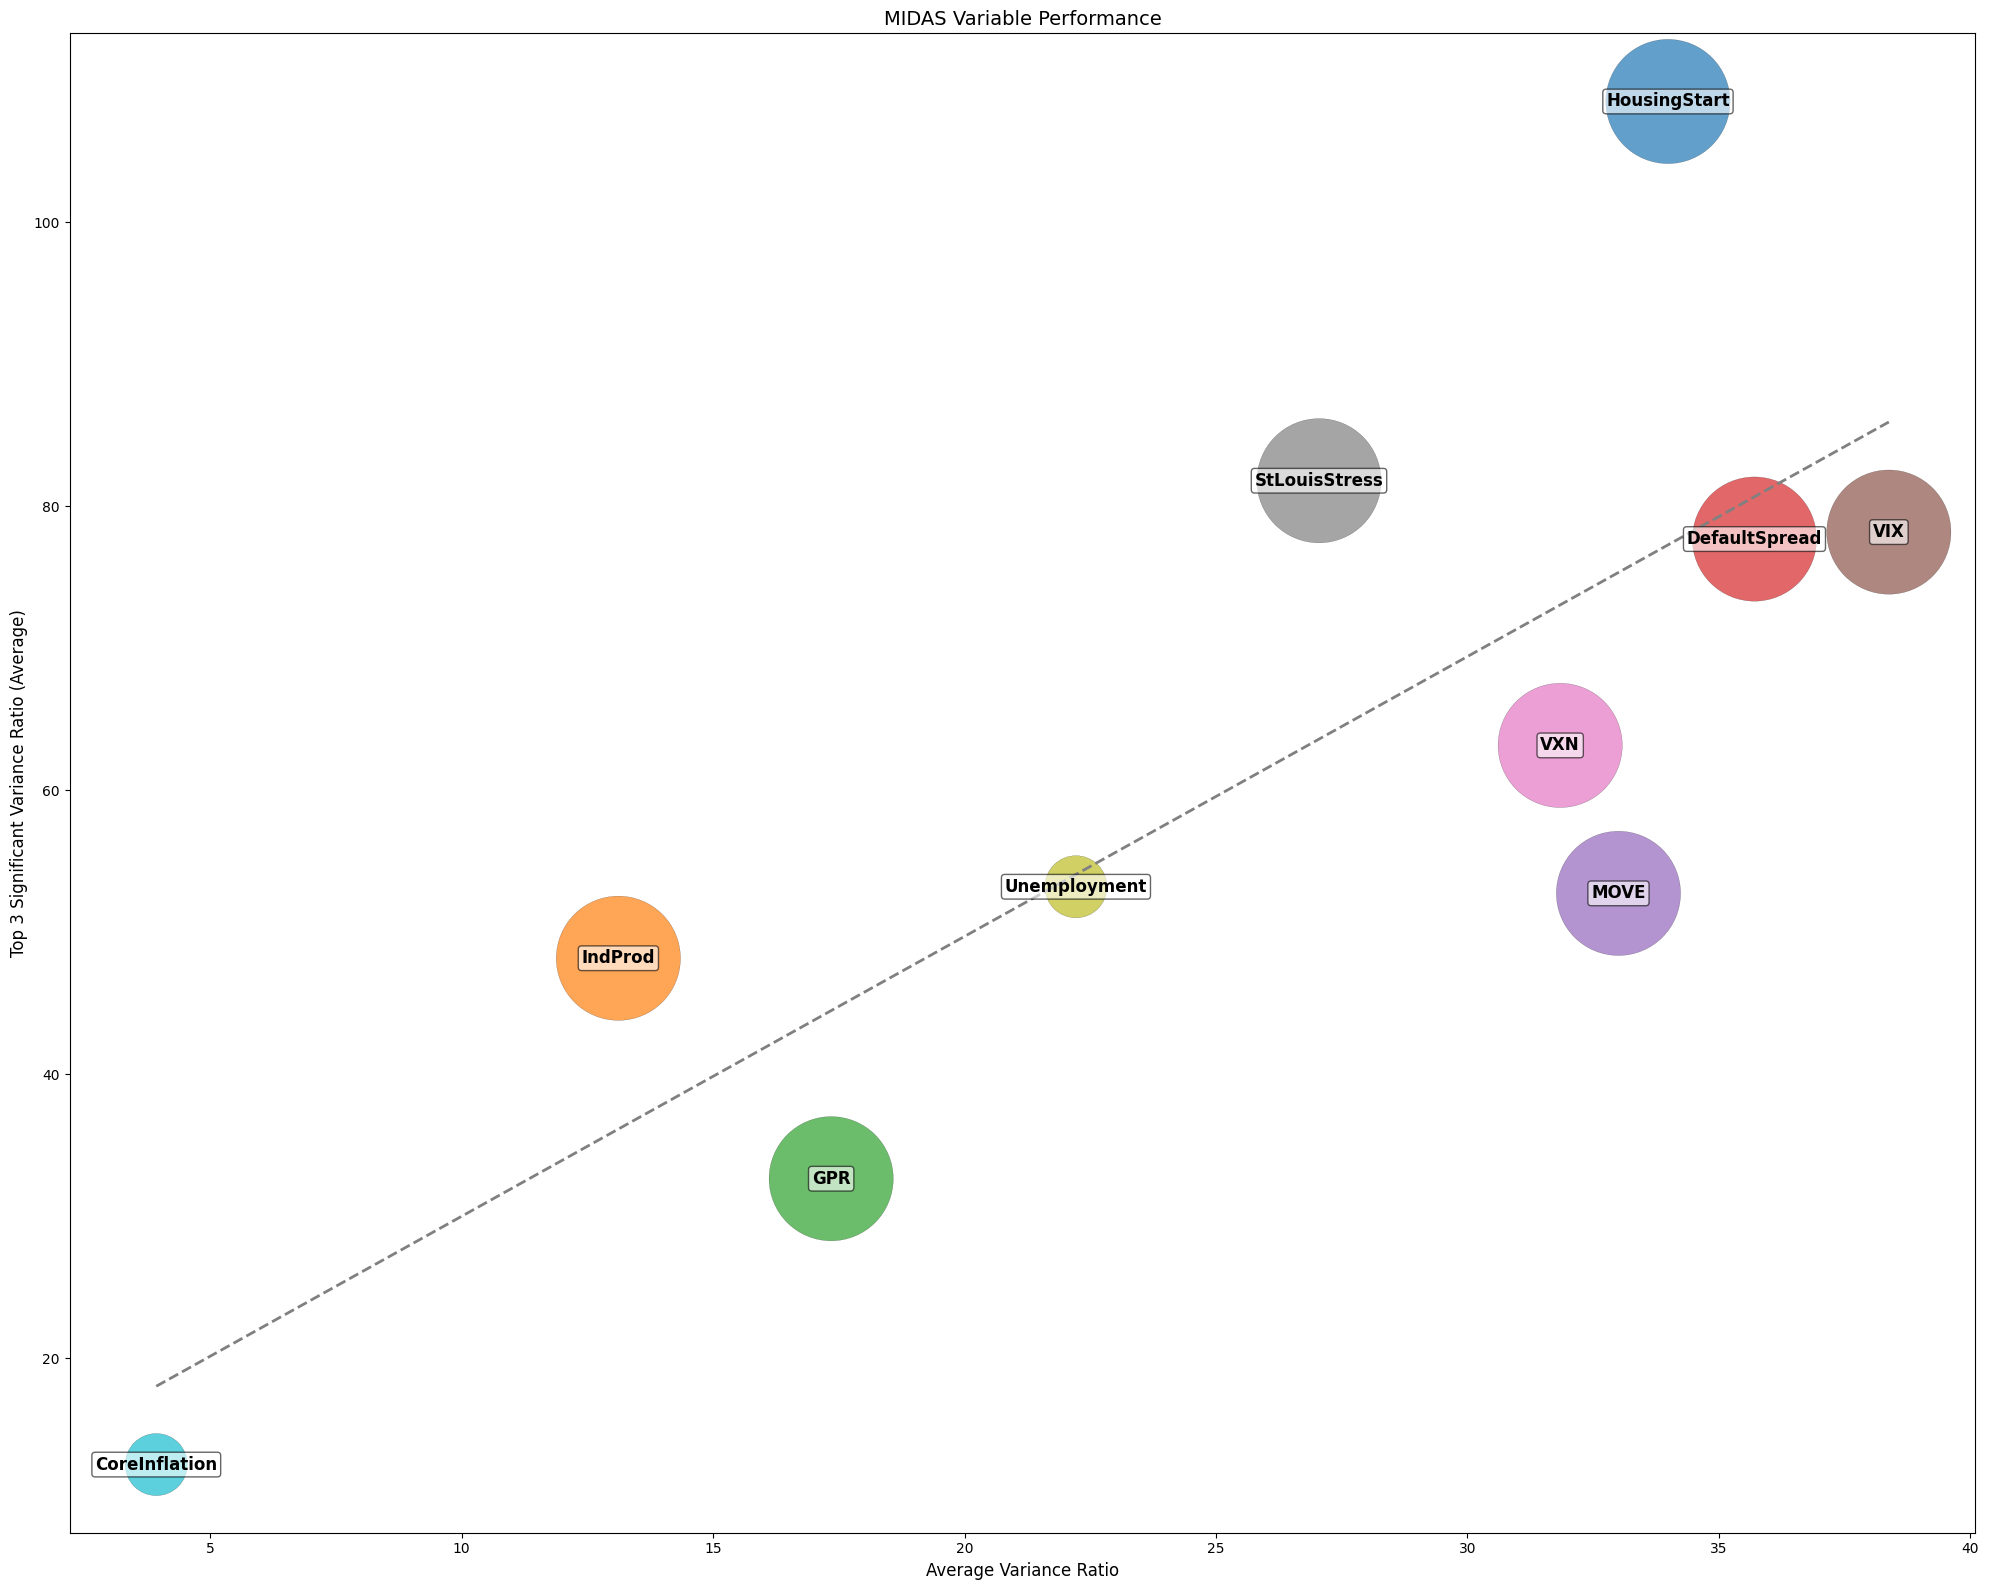

,MIDAS Variable,Significant_Count,Avg_VR,Top3_Avg_VR
8,HousingStart,14,33.988244,108.496917
9,IndProd,14,13.117170,48.171896
7,GPR,14,17.348550,32.650054
4,DefaultSpread,14,35.708598,77.687363
10,MOVE,14,33.004101,52.739544
18,VIX,14,38.380567,78.177590
19,VXN,14,31.845209,63.158188
14,StLouisStress,14,27.049325,81.794730
17,Unemployment,13,22.216181,53.206471
3,CoreInflation,13,3.928158,12.521921


In [378]:
visualize_midas_performance(df)

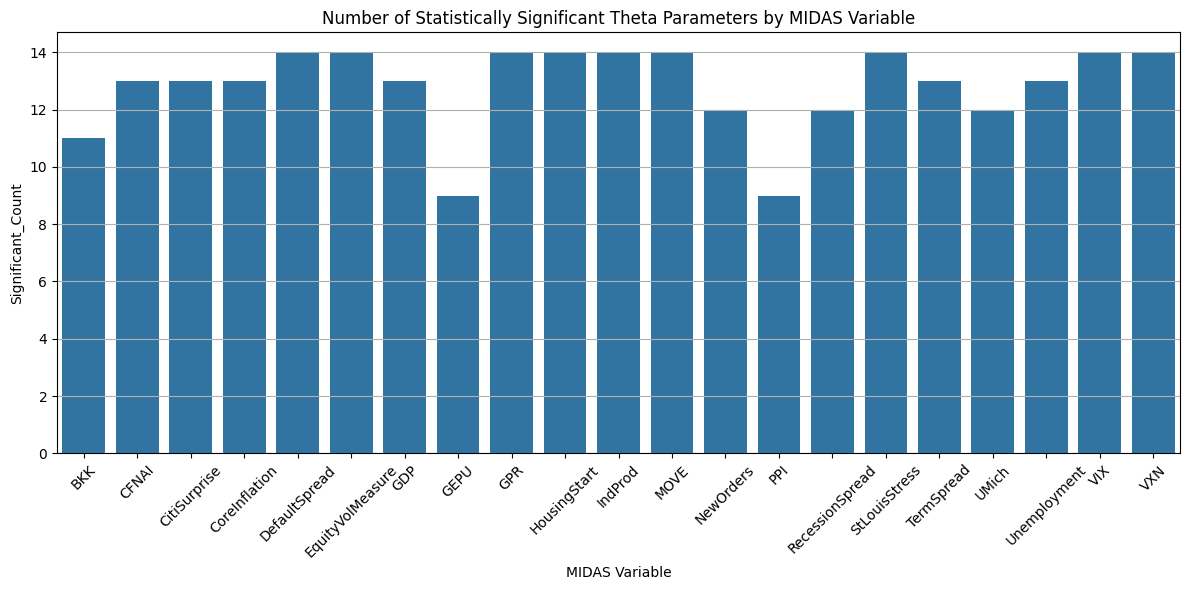

,MIDAS Variable,Significant_Count
0,BKK,11
1,CFNAI,13
2,CitiSurprise,13
3,CoreInflation,13
4,DefaultSpread,14
5,EquityVolMeasure,14
6,GDP,13
7,GEPU,9
8,GPR,14
9,HousingStart,14


In [254]:
plot_significant_counts_bar(df)

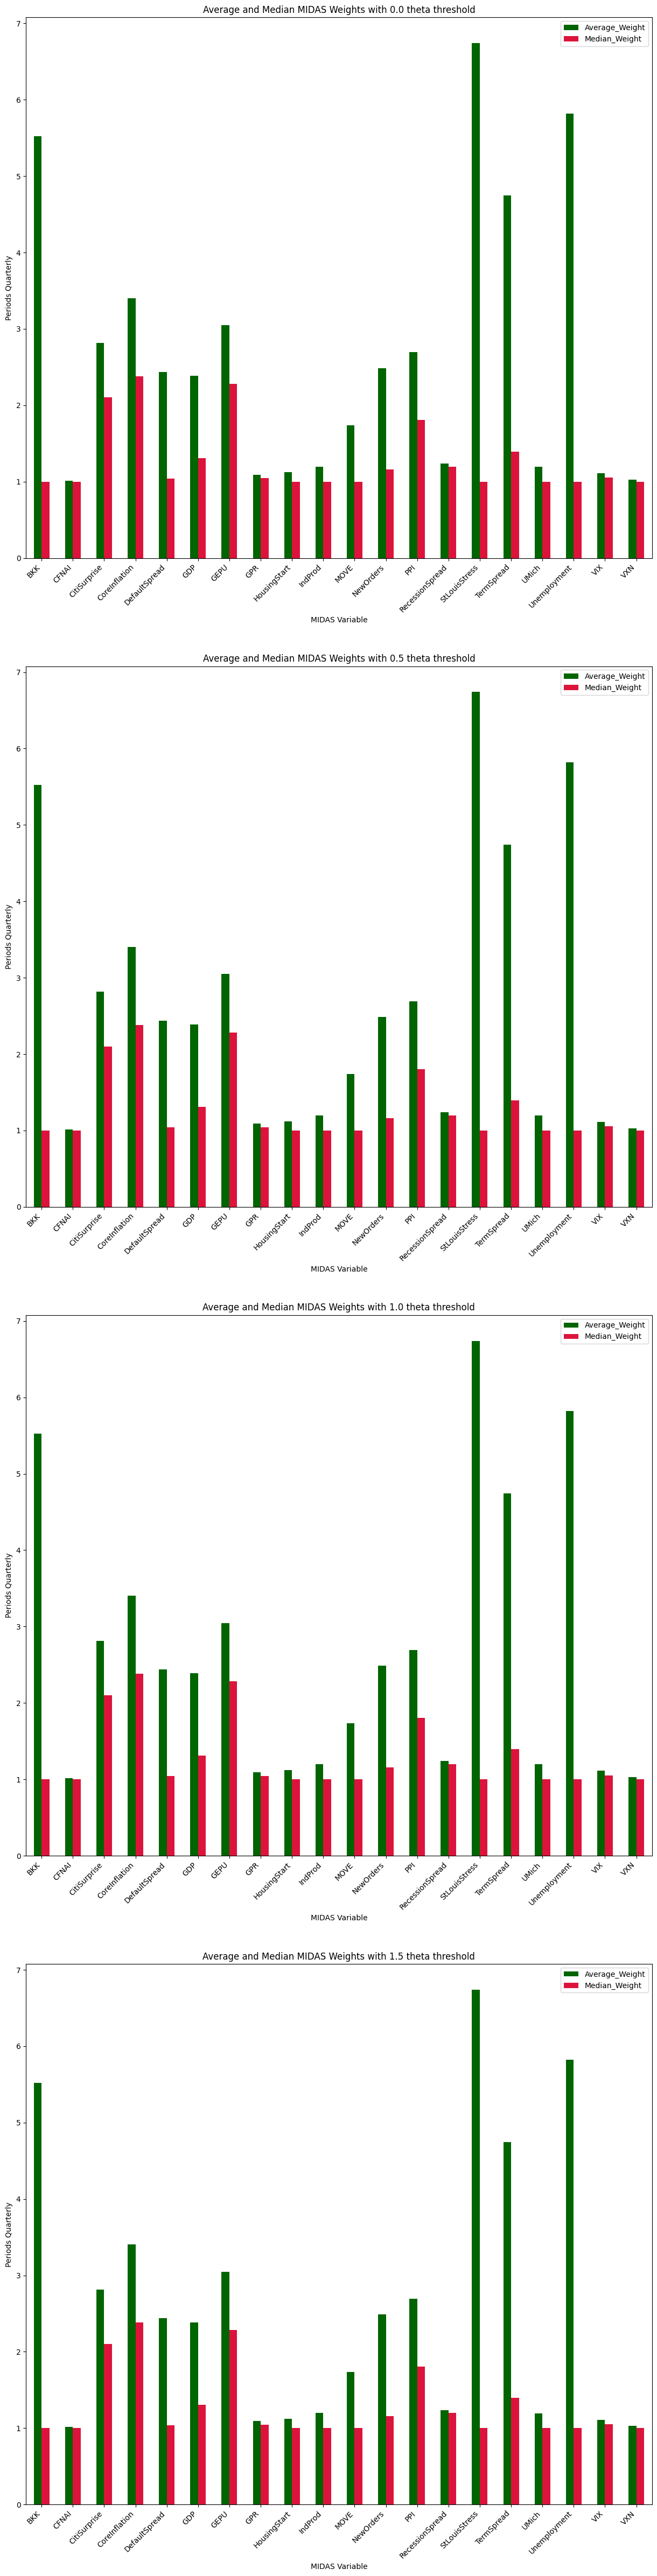

In [381]:
fig, axs = plt.subplots(4, 1, figsize = (15, 60))
thresholds = np.arange(0, 2, 0.5)
axes = axs.flatten()

for count, threshold in enumerate(thresholds):
    plot_average_weights(df, axes[count], threshold = threshold, frequency = 'Quarterly')


## Quarterly Sector Indices

In [339]:
df_Q_Sector = pd.read_csv('Quarterly SECTOR GARCH MIDAS R v3.csv')
df_Q_Sector = Reformat_GARCH_Analysis(df_Q_Sector)

In [ ]:
fig, axs = plt.subplots(4, 1, figsize = (15, 60), sharex = True, sharey = True)
thresholds = np.arange(0, 2, 0.5)
axes = axs.flatten()

for count, threshold in enumerate(thresholds):
    plot_average_weights(df, axes[count], threshold)

TypeError: plot_average_weights() missing 1 required positional argument: 'ax'